## Import Helper Function and Parameter

In [1]:
cd("d:/Master Research/Research-Project")

In [2]:
include(joinpath(@__DIR__, "..", "Helper_util", "util.jl"))
include(joinpath(@__DIR__, "..", "Parameter", "parameter.jl"));

## Parameter Definition

In [6]:
## Define the diffusion coefficients and wave WaveNumber
diffusion_coefficient = DiffusionParameter(1, 0.01, 0.01, 0.01)


total_population=Total_Population(1.75).total


## parameter setting up 2
Nₜ = global_parameter_2.Nₜ
λ, ν = global_parameter_2.λ, global_parameter_2.ν
δ, g, m = global_parameter_2.δ, global_parameter_2.g, global_parameter_2.m
d₁, d₂, d₃, d₄, k = diffusion_coefficient.d₁, diffusion_coefficient.d₂, diffusion_coefficient.d₃, diffusion_coefficient.d₄, WaveNumber(2).k;
d₁_vec=Diffusion_Vec_Parameter(0.01:0.001:1).d_vec;


## MAX real part of PDE v.s. WaveNumber k

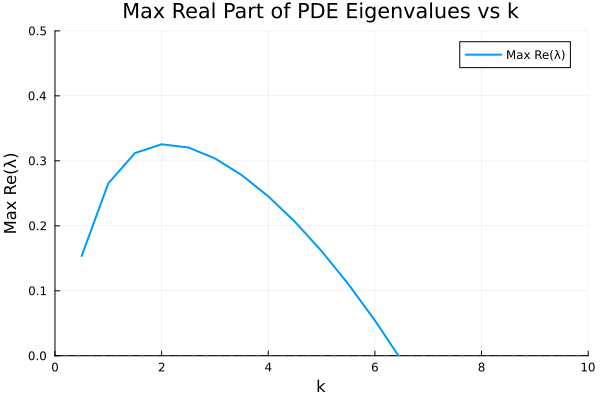

In [4]:
k_values=0.5:0.5:10
plot_pde_eigenvalues_3D(total_population, λ, ν, δ, g, m, d₁, d₂, d₃, k_values, (0, 10), (0, 0.5))

## Heat map with various diffusion coefficient d1

In [14]:
ODE_eigen = zeros(Float64, length(Nₜ), length(d₁_vec))
PDE_eigen = zeros(Float64, length(Nₜ), length(d₁_vec))

for i in 1:length(d₁_vec)
    for j in 1:length(Nₜ)
        ODE_eigen[j,i], PDE_eigen[j,i], _ = ODE_PDE_system_3D(Nₜ, λ, ν, δ, g, m, d₁_vec[i], d₂, d₃, k)[j]
    end
end

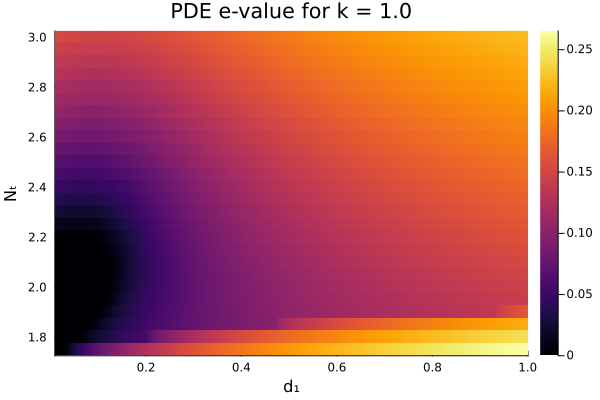

In [15]:
heatmap(d₁_vec, Nₜ, max.(PDE_eigen, 0),
    xlabel = "d₁",
    ylabel = "Nₜ",
    title = "PDE e-value for k = $k",  # Ensure aspect ratio is equal for clarity
    colorbar = true,
)

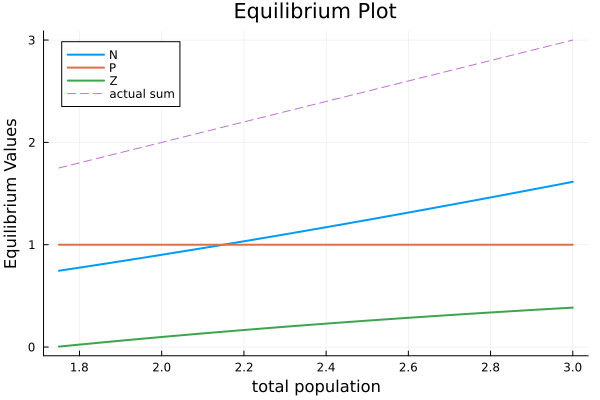

In [16]:
plot_equilibrium_3D(Nₜ, λ, ν, δ, g, m)

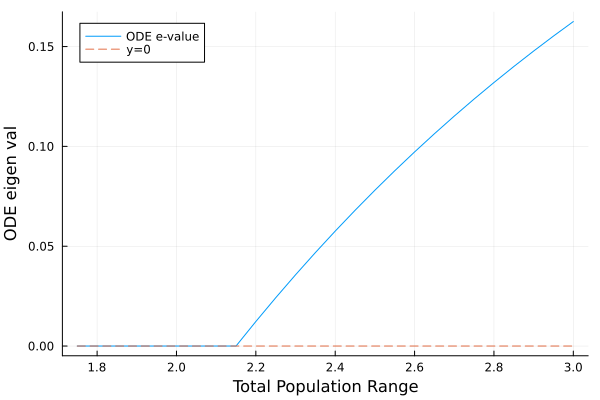

In [17]:
plot(Nₜ, ODE_eigen[:,1], xlabel="Total Population Range", ylabel="ODE eigen val", label="ODE e-value")
plot!(Nₜ, zeros(length(Nₜ)), label="y=0", linestyle=:dash)

## Heat map with various wave number k

In [8]:
## Running Heatmap for various wave number k
Nₜ = 1.75:0.01:3
λ, ν = 0.85, 2
δ, g, m = 1, 2, 1/2
d₂, d₃, d₁ = 0, 0.01, 1
k_values=1:0.5:41

PDE_eigen = zeros(Float64, length(Nₜ), length(k_values))

for i in 1:length(k_values)
    for j in 1:length(Nₜ)
        _, PDE_eigen[j,i], _ = ODE_PDE_system_3D(Nₜ, λ, ν, δ, g, m, d₁, d₂, d₃, k_values[i])[j]
    end
end


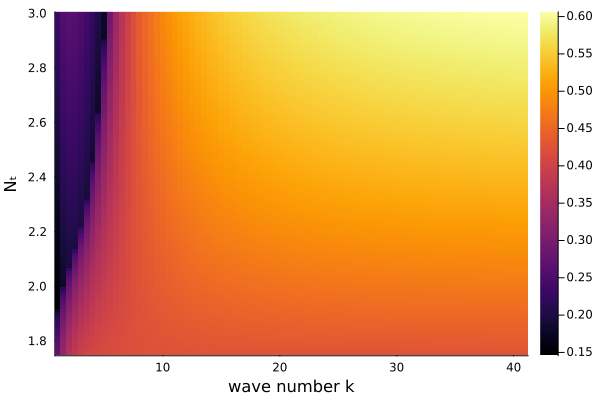

In [9]:
heatmap(k_values, Nₜ, max.(PDE_eigen, 0),
    xlabel = "wave number k",
    ylabel = "Nₜ",
    colorbar = true,
)

## Stable Equilibrium

we decide to set up 2 different total population corresponding to 2 different modes in the heat map

In [7]:
N̄, P̄, Z̄= equilibrium_state_3D(total_population, λ, ν, δ, g, m)

N̄, P̄, Z̄=N̄[1], P̄[1], Z̄[1]

(0.745683229480096, 1.0, 0.0043167705199040896)

## Initial Condition

In [8]:
function N_initial_cond(x)
    C₁=real(ODE_PDE_system_3D(total_population, λ, ν, δ, g, m, d₁, d₂, d₃, k)[1][4][1])
    N = N̄+1e-4*C₁*cos(k*x)
    return(N)
end


function P_initial_cond(x)
    C₂=real(ODE_PDE_system_3D(total_population, λ, ν, δ, g, m, d₁, d₂, d₃, k)[1][4][2])
    P = P̄+1e-4*C₂*cos(k*x)
    return(P)
end

function Z_initial_cond(x)
    C₃=real(ODE_PDE_system_3D(total_population, λ, ν, δ, g, m, d₁, d₂, d₃, k)[1][4][3])
    Z = Z̄+1e-4*C₃*cos(k*x)
    return(Z)
end

Z_initial_cond (generic function with 1 method)

In [20]:
function random_IC_N(x)
    noise = rand(Normal(0, 1e-3))
    return N̄ + noise
end

function random_IC_P(x)
    noise = rand(Normal(0, 1e-3))
    return P̄ + noise
end

function random_IC_Z(x)
    noise = rand(Normal(0, 1e-3))
    return Z̄ + noise
end

random_IC_Z (generic function with 1 method)

## Model setting up

In [21]:
## Initialize the model
NPZ_parameters =  ( d₁ = d₁,
                    d₂ = d₂,
                    d₃ = d₃,
                    ν = ν ,          
                    λ = λ ,
                    δ = δ,
                    g = g,
                    m = m
)



growth_P(z, t, N, P, Z, params) = params.ν * P * N / (N + 1)
death_P(z, t, N, P, Z, params) = params.λ*(max(0, P))^(params.m)

growth_Z(z, t, N, P, Z, params) = params.g * Z * P / (P + 1)
death_Z(z, t, N, P, Z, params) = params.δ * Z





N_reaction(z, t, N, P, Z, params) = - growth_P(z, t, N, P, Z, params) + death_P(z, t, N, P, Z, params) + death_Z(z, t, N, P, Z, params)

P_reaction(z, t, N, P, Z, params)=   growth_P(z, t, N, P, Z, params) - death_P(z, t, N, P, Z, params) - growth_Z(z, t, N, P, Z, params)

Z_reaction(z, t, N, P, Z, params) =  growth_Z(z, t, N, P, Z, params) - death_Z(z, t, N, P, Z, params)


N_forcing = Forcing(N_reaction, field_dependencies = (:N, :P, :Z), parameters = NPZ_parameters)
P_forcing = Forcing(P_reaction, field_dependencies = (:N, :P, :Z), parameters = NPZ_parameters)
Z_forcing = Forcing(Z_reaction, field_dependencies = (:N, :P, :Z), parameters = NPZ_parameters)


grid = RectilinearGrid(size=64, z=(0,2*π), topology=(Flat, Flat, Bounded))

diffusivities = NamedTuple{(:N, :P, :Z)}((NPZ_parameters.d₁, NPZ_parameters.d₂, NPZ_parameters.d₃))

closure = ScalarDiffusivity(κ=diffusivities)

model   = NonhydrostaticModel(; grid,
                             closure,
                             tracers = (:N, :P, :Z),
                             forcing = (N=N_forcing, P=P_forcing, Z=Z_forcing)
                             )

NonhydrostaticModel{CPU, RectilinearGrid}(time = 0 seconds, iteration = 0)
├── grid: 1×1×64 RectilinearGrid{Float64, Flat, Flat, Bounded} on CPU with 0×0×3 halo
├── timestepper: RungeKutta3TimeStepper
├── advection scheme: Centered(order=2)
├── tracers: (N, P, Z)
├── closure: ScalarDiffusivity{ExplicitTimeDiscretization}(ν=0.0, κ=(N=1.0, P=0.01, Z=0.01))
├── buoyancy: Nothing
└── coriolis: Nothing

In [22]:
## Define the initial condition:
set!(model, N = random_IC_N, P = random_IC_P, Z = random_IC_Z)
min_Δz = minimum_zspacing(model.grid)
diffusion_time_scale = min_Δz^2 / model.closure.κ.N;

## Run simulation

In [23]:
## Running simulation
max_time= 40
simulation = Simulation(model, Δt =  0.1*diffusion_time_scale, stop_time = max_time)

########################################

N, P, Z = model.tracers

perturbation_N(args...) = norm(N .- N̄)
perturbation_P(args...) = norm(P .- P̄)
perturbation_Z(args...) = norm(Z .- Z̄)

simulation.output_writers[:growth_NPZ] =
    NetCDFOutputWriter(model, (; perturbation_N, perturbation_P, perturbation_Z);
                     filename = "NPZgrowth.nc",
                     schedule = IterationInterval(10),
                     dimensions = (; perturbation_N = (),
                                     perturbation_P = (),
                                     perturbation_Z = ()),
                     overwrite_existing = true)

simulation.output_writers[:fields] =
    JLD2OutputWriter(model, model.tracers,
                     filename = "NPZ.jld2",
                     schedule=IterationInterval(200),
                     overwrite_existing = true)

run!(simulation)

┌ Warning: Overwriting existing d:\Master Research\Research-Project\NPZgrowth.nc.
└ @ Oceananigans.OutputWriters C:\Users\xiang\.julia\packages\Oceananigans\2NE0o\src\OutputWriters\netcdf_output_writer.jl:397
┌ Info: Initializing simulation...
└ @ Oceananigans.Simulations C:\Users\xiang\.julia\packages\Oceananigans\2NE0o\src\Simulations\run.jl:202
┌ Info:     ... simulation initialization complete (1.628 seconds)
└ @ Oceananigans.Simulations C:\Users\xiang\.julia\packages\Oceananigans\2NE0o\src\Simulations\run.jl:245
┌ Info: Executing initial time step...
└ @ Oceananigans.Simulations C:\Users\xiang\.julia\packages\Oceananigans\2NE0o\src\Simulations\run.jl:141
┌ Info:     ... initial time step complete (1.316 seconds).
└ @ Oceananigans.Simulations C:\Users\xiang\.julia\packages\Oceananigans\2NE0o\src\Simulations\run.jl:170
┌ Info: Simulation is stopping after running for 0 seconds.
└ @ Oceananigans.Simulations C:\Users\xiang\.julia\packages\Oceananigans\2NE0o\src\Simulations\simulation.

## ODE stability

In [ ]:
N_data,P_data,Z_data,times,space= key_variable_outcome_3D(20, model, "NPZ.jld2");

In [ ]:
surface_plot_3D(N_data,P_data,Z_data,times,space)

## Cos(2x)

In [12]:
N_data,P_data,Z_data,times,space= key_variable_outcome_3D(39, model, "NPZ.jld2");

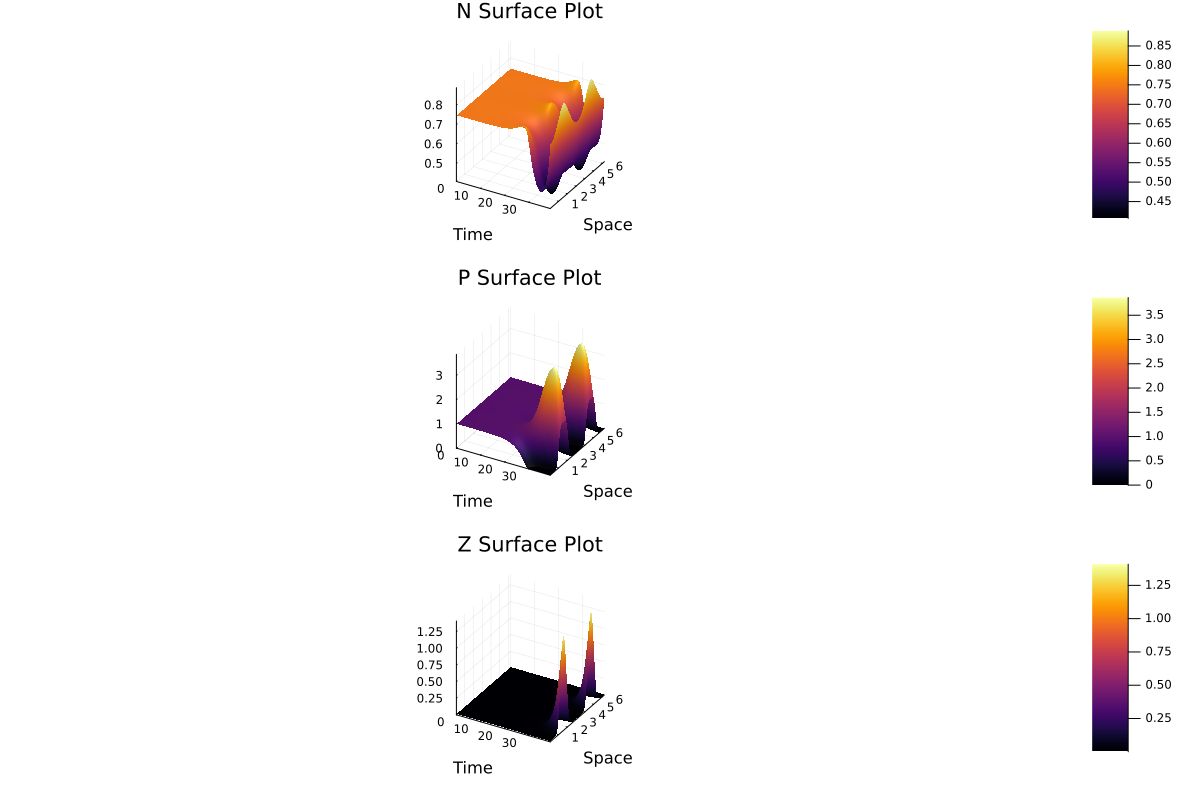

In [14]:
surface_plot_3D(N_data,P_data,Z_data,times,space)

In [17]:

function experiment_growth_rate_3D(file_name,total_population, I₁, I₂, I₃, λ, ν, δ, g, m, d₁, d₂, d₃, k)
    ds = NCDataset(file_name, "r")
    times = ds["time"][:]

    ## Denote the perturbation for N and P from the equilibrium state
    N′ = ds["perturbation_N"]
    P′ = ds["perturbation_P"]
    Z′ = ds["perturbation_Z"]
    time_increment=40/size(times)[1]

    

    Interval_1=Int(round(I₁[1]/time_increment)):Int(round(I₁[size(I₁)[1]]/time_increment))
    Interval_2=Int(round(I₂[1]/time_increment)):Int(round(I₂[size(I₂)[1]]/time_increment))
    Interval_3=Int(round(I₃[1]/time_increment)):Int(round(I₃[size(I₃)[1]]/time_increment))
    degree = 1

    ## Fit the log of growth with line on time range I for N,P
    
    linear_fit_N = fit(times[Interval_1], log.(N′[Interval_1]), degree, var = :t)
    best_fit_N = @. exp(linear_fit_N[0] + linear_fit_N[1] * times)
    
    linear_fit_P = fit(times[Interval_2], log.(P′[Interval_2]), degree, var = :t)
    best_fit_P = @. exp(linear_fit_P[0] + linear_fit_P[1] * times)

    linear_fit_Z = fit(times[Interval_3], log.(Z′[Interval_3]), degree, var = :t)
    best_fit_Z = @. exp(linear_fit_Z[0] + linear_fit_Z[1] * times)



    # ODE_PDE_system_3D(total_population, λ, ν, δ, g, m, d₁, d₂, d₃, k)[1][2]

    print("Growth rate of N is approximately ", linear_fit_N[1] , "\n")
    print("Growth rate of P is approximately ", linear_fit_P[1] , "\n")
    print("Growth rate of Z is approximately ", linear_fit_Z[1] , "\n")
    print("Largest real part of e-value ", ODE_PDE_system_3D(total_population, λ, ν, δ, g, m, d₁, d₂, d₃, k)[1][2])

    


    plot(times, N′,label="norm(N′)", yscale = :log10, linestyle=:solid,
    lw=4, xlabel="time", ylabel="norm",title="Norm of perturbations", legend=:topleft)


    plot!(times, P′,label="norm(P′)", linestyle=:solid, lw=4)#

    plot!(times, Z′,label="norm(Z′)", linestyle=:solid, lw=4)#
    
    plot!(times[Interval_1], best_fit_N[Interval_1],label="N best fit", linestyle=:dash, lw=6)
    
    plot!(times[Interval_2], best_fit_P[Interval_2],label="P best fit", linestyle=:dash, lw=6)

    plot!(times[Interval_3], best_fit_Z[Interval_3],label="Z best fit", linestyle=:dash, lw=6)

end


experiment_growth_rate_3D (generic function with 1 method)

Growth rate of N is approximately 0.3254279348883459
Growth rate of P is approximately 0.3254340299692656
Growth rate of Z is approximately 0.3254938516795974
Largest real part of e-value 0.32547273983257763

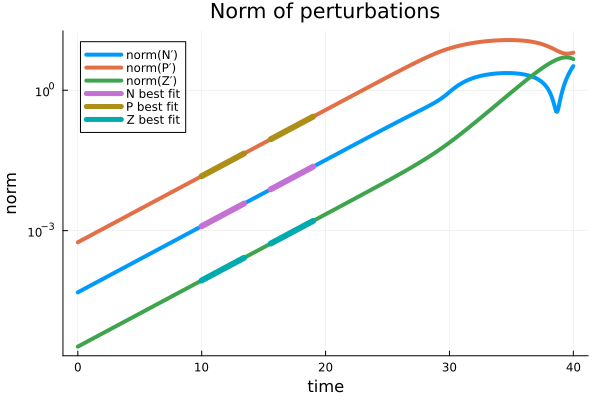

In [19]:
experiment_growth_rate_3D("NPZgrowth.nc",total_population, 10:20, 10:20, 10:20, λ, ν, δ, g, m, d₁, d₂, d₃, k)

## Random Initial Condition

In [24]:
N_data,P_data,Z_data,times,space= key_variable_outcome_3D(39, model, "NPZ.jld2");

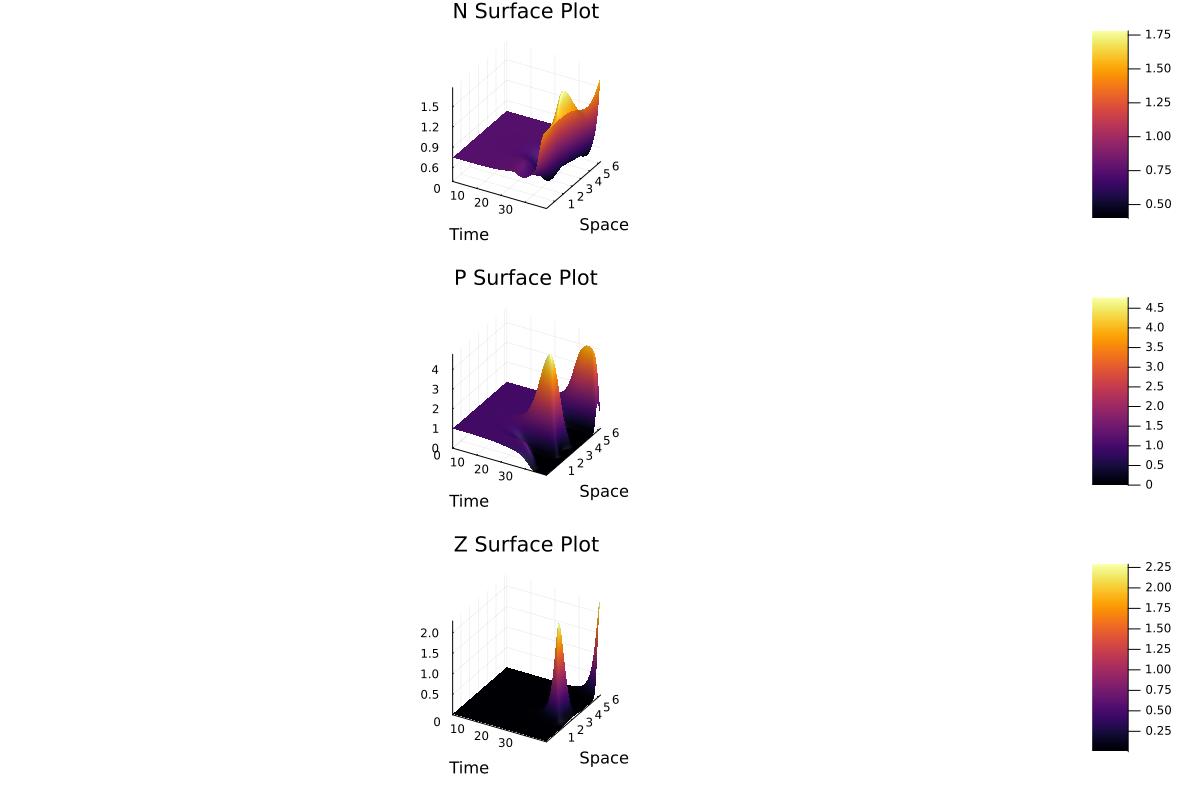

In [25]:
surface_plot_3D(N_data, P_data,Z_data,times,space)

Growth rate of N is approximately 0.24886926479563276
Growth rate of P is approximately 0.28830021088646735
Growth rate of Z is approximately 0.3543458387684764
Largest real part of e-value 0.32547273983257763

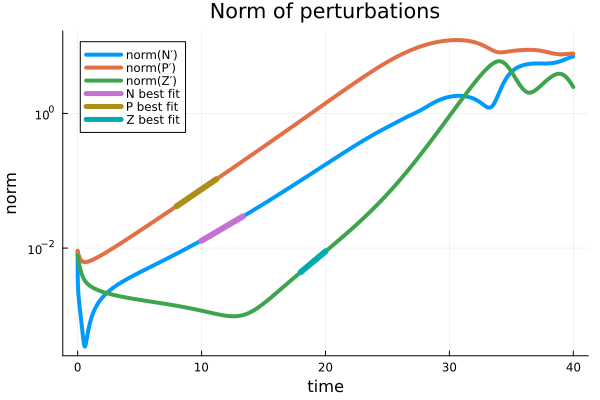

In [26]:
experiment_growth_rate_3D("NPZgrowth.nc",total_population,
                                        10:15, ## Fitting range for N
                                        8:13,  ## Fitting range for P
                                        18:20, ## Fitting range for Z
                                        λ, ν, δ, g, m, d₁, d₂, d₃, 2)

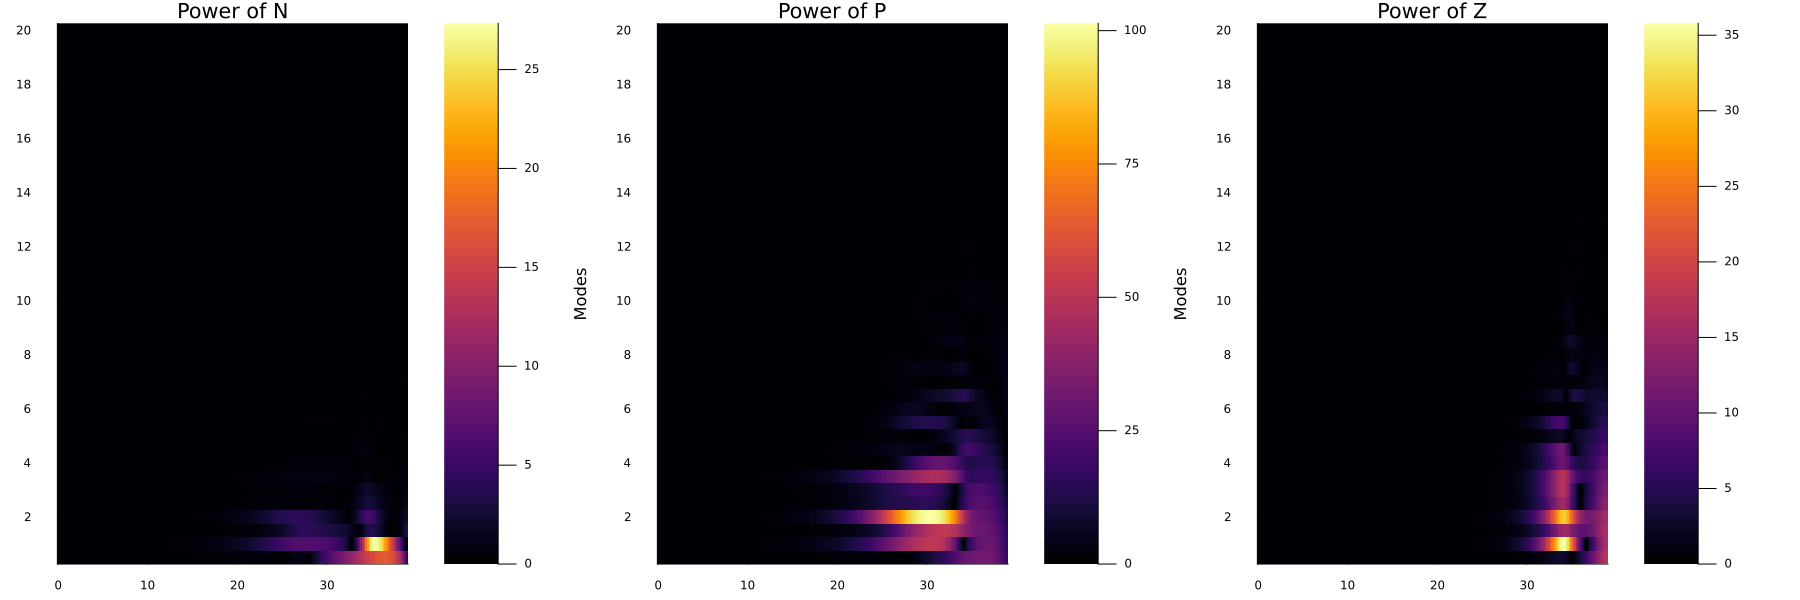

In [28]:
FFT_power_3D(N_data, P_data, Z_data, N̄, P̄, Z̄, times)

In [30]:
print("real part of eigenvalue with k=2: ",real(ODE_PDE_system_3D(total_population, λ, ν, δ, g, m, d₁, d₂, d₃, 2)[1][5])," with oscilation period " ,2*π/abs(imag(ODE_PDE_system_3D(total_population, λ, ν, δ, g, m, d₁, d₂, d₃, 2)[1][5])))

real part of eigenvalue with k=2: 0.32547273983257763 with oscilation period Inf

In [31]:
print("real part of eigenvalue with k=1.5: ",real(ODE_PDE_system_3D(total_population, λ, ν, δ, g, m, d₁, d₂, d₃, 1.5)[1][5])," with oscilation period " ,2*π/abs(imag(ODE_PDE_system_3D(total_population, λ, ν, δ, g, m, d₁, d₂, d₃, 1.5)[1][5])))

real part of eigenvalue with k=1.5: 0.31197147528376257 with oscilation period Inf

In [32]:
print("real part of eigenvalue with k=1: ",real(ODE_PDE_system_3D(total_population, λ, ν, δ, g, m, d₁, d₂, d₃, 1)[1][5])," with oscilation period " ,2*π/abs(imag(ODE_PDE_system_3D(total_population, λ, ν, δ, g, m, d₁, d₂, d₃, 1)[1][5])))

real part of eigenvalue with k=1: 0.265375647916469 with oscilation period Inf

In [33]:
print("real part of eigenvalue with k=0.5: ",real(ODE_PDE_system_3D(total_population, λ, ν, δ, g, m, d₁, d₂, d₃, 0.5)[1][5])," with oscilation period " ,2*π/abs(imag(ODE_PDE_system_3D(total_population, λ, ν, δ, g, m, d₁, d₂, d₃, 0.5)[1][5])))

real part of eigenvalue with k=0.5: 0.1535405612206537 with oscilation period Inf